# Grover's Algorithm

**Finding a needle in a haystack — explained simply, with runnable Qiskit code**

---

Grover's algorithm is quantum computing's famous **search** trick. Imagine a phone book with a million names, but it's shuffled into random order. You want the one person with a specific unlisted number. There's no clever shortcut — you'd have to check names one at a time until you get lucky. On average, half a million checks.

Grover's algorithm finds that person in about **a thousand** checks instead of a million. Not by being clever about the order (there is no order), but by using quantum interference to make the right answer *louder* and the wrong answers *quieter*, over and over, until the right one is easy to hear.

### How it's different from Simon's and Shor's

If you've seen the Simon's and Shor's notebooks, here's the honest comparison up front:

- **Simon's and Shor's** exploit a *hidden pattern* (a mirror, a rhythm). That pattern lets them cancel wrong answers **all at once**, giving an enormous exponential speedup.
- **Grover's** works when there is **no pattern at all** — a pure needle-in-a-haystack. With nothing to exploit, it can only nudge the answer louder a little bit each round. So its speedup is smaller: **quadratic**, not exponential. A million shrinks to a thousand (√1,000,000 = 1,000), not to twenty.

That smaller speedup is not a flaw — it's a law. You simply cannot do better than √N when the haystack has no structure. Grover's hits that limit exactly.

| | Classical search | Grover's search |
|---|---|---|
| Checks needed (haystack of N) | about N | about √N |
| N = 1,000,000 | ~1,000,000 | ~1,000 |
| Speedup | — | Quadratic (square-root) |

---

*(c) 2026 David Grunwald. All rights reserved.*

## 0. Setup

If Qiskit isn't installed, uncomment and run the cell below.

On Windows with a specific Python install, prefer the full path from a terminal:
`C:\python3_13\python.exe -m pip install qiskit qiskit-aer matplotlib pylatexenc`

In [1]:
# !pip install qiskit qiskit-aer matplotlib pylatexenc

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import numpy as np
from math import floor, pi, asin, sin

import qiskit, qiskit_aer
print("qiskit    ", qiskit.__version__)
print("qiskit-aer", qiskit_aer.__version__)

qiskit     2.5.0
qiskit-aer 0.17.2


## 1. The two magic moves

Grover's algorithm repeats a pair of moves over and over. Picture all the possible answers laid out as bars of equal height (equal "loudness"). One of them is the secret answer we want.

**Move 1 — The Oracle (flip the winner).** The oracle is the machine that knows the answer — it can *recognize* the right one even though it can't *tell* you which it is. Its job is tiny: it flips the winner's bar upside down (below zero), and leaves everyone else alone. Nobody's height changes, only the winner's *sign*.

> Think of it as invisible ink. The oracle secretly marks the winner with a minus sign. You can't see the mark yet — all the bars still *look* the same height — but the next move will develop it.

**Move 2 — The Diffuser (flip everyone around the average).** This is the clever part. It takes every bar and reflects it around the *average* height of all the bars. Because the winner was pushed below zero, the average is dragged slightly down — and reflecting the winner around that lowered average launches it way up tall, while everyone else shrinks a little.

Together, one Oracle + one Diffuser = the winner gets taller, everyone else gets shorter. Do it the right number of times, and the winner towers over the rest. Measure, and you almost certainly get the winner.

> **The one thing to remember:** Move 1 marks the winner with a secret sign. Move 2 turns that secret sign into visible height. This pair is often called the **Grover operation**.

## 2. The Oracle — recognizing the winner

Here we build the oracle. It flips the sign of whichever answer(s) we mark as "correct." Below, the marked answers are just bit-strings like `"101"`.

> ⚠️ **The endianness trap** (same one from Simon's). Qiskit numbers qubit 0 as the **rightmost** character of a measured string. So we reverse the marked string before wiring it up. Skip the reversal and the oracle marks a *mirrored* answer — the circuit runs, but Grover's happily amplifies the wrong bar.

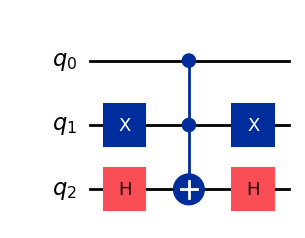

In [3]:
def phase_oracle(n, marked):
    "Flip the sign of every 'marked' answer, leave all others alone."
    qc = QuantumCircuit(n, name="oracle")
    for m in marked:
        rev = m[::-1]                         # <-- endianness fix
        # X gates turn the target pattern into all-1s so a controlled-Z can hit it
        zeros = [i for i, b in enumerate(rev) if b == "0"]
        for i in zeros:
            qc.x(i)
        # multi-controlled Z: flips the sign only when every qubit is 1
        if n == 1:
            qc.z(0)
        else:
            qc.h(n - 1)
            qc.mcx(list(range(n - 1)), n - 1)
            qc.h(n - 1)
        for i in zeros:
            qc.x(i)
    return qc


# peek at an oracle that recognizes "101"
phase_oracle(3, ["101"]).draw(output="mpl", fold=-1)

## 3. The Diffuser — reflecting around the average

The diffuser does the "flip everyone around the average" move. In quantum terms it's a reflection about the *equal-blend* state. The recipe is a tidy sandwich: Hadamards, then flip about all-zeros, then Hadamards again.

You don't need to trace every gate. The important idea: **this is the amplifier.** It's identical no matter what we're searching for — it doesn't even know the answer. All the answer-specific knowledge lives in the oracle.

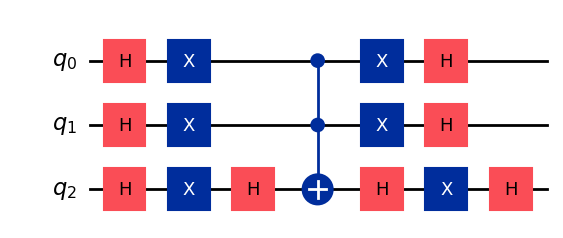

In [4]:
def diffuser(n):
    "Reflect all answers about their average height (the amplify step)."
    qc = QuantumCircuit(n, name="diffuser")
    for i in range(n):
        qc.h(i)
    for i in range(n):
        qc.x(i)
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)         # flip sign of all-zeros
    qc.h(n - 1)
    for i in range(n):
        qc.x(i)
    for i in range(n):
        qc.h(i)
    return qc


diffuser(3).draw(output="mpl", fold=-1)

## 4. How many times to repeat? (The Goldilocks number)

Here's the surprise that trips people up: **more repetitions is not always better.**

Each Grover round rotates the winner a fixed step taller. But if you keep going *past* the peak, the winner starts shrinking again — you overshoot and rotate right past the answer. So there's a "just right" number of rounds: not too few, not too many.

The magic count is:

$$t = \left\lfloor \frac{\pi}{4}\sqrt{\frac{N}{s}} \right\rfloor$$

where `N` is the size of the haystack and `s` is how many winners there are. That `√N` is the whole reason Grover's is fast — you finish in about square-root-of-N rounds.

Let's compute it, then *watch* the overshoot happen so the warning sinks in.

In [5]:
def optimal_iterations(n, s):
    "The Goldilocks number of Grover rounds."
    N = 2 ** n
    theta = asin(np.sqrt(s / N))
    return floor(pi / (4 * theta))


def success_probability(n, s, t):
    "Chance of measuring a winner after t rounds (exact formula)."
    N = 2 ** n
    theta = asin(np.sqrt(s / N))
    return sin((2 * t + 1) * theta) ** 2


# Watch the winner rise, peak, then FALL if we over-rotate.
# Haystack of 16, one winner.
print("Searching N = 16 for 1 winner")
print(f"{'rounds t':<10}{'success chance':<16}{'note'}")
print("-" * 45)
best = optimal_iterations(4, 1)
for t in range(0, 9):
    p = success_probability(4, 1, t)
    note = "  <-- Goldilocks (best)" if t == best else ("  overshooting!" if t > best else "")
    print(f"{t:<10}{p:<16.4f}{note}")

Searching N = 16 for 1 winner
rounds t  success chance  note
---------------------------------------------
0         0.0625          
1         0.4727          
2         0.9084          
3         0.9613            <-- Goldilocks (best)
4         0.5817            overshooting!
5         0.1255            overshooting!
6         0.0204            overshooting!
7         0.3649            overshooting!
8         0.8361            overshooting!


See it climb to nearly certain, then *tumble back down*? That's why you can't just "run it a lot." The IBM course calls over-rotating past the target **catastrophic** — you can rotate all the way past the answer and land on nonsense. Grover's rewards precision, not brute force.

## 5. The full circuit

Now we chain it together: start with an equal blend (all bars the same height), then repeat Oracle + Diffuser the Goldilocks number of times, then measure.

Searching 8 answers for ['101'], using t = 2 rounds


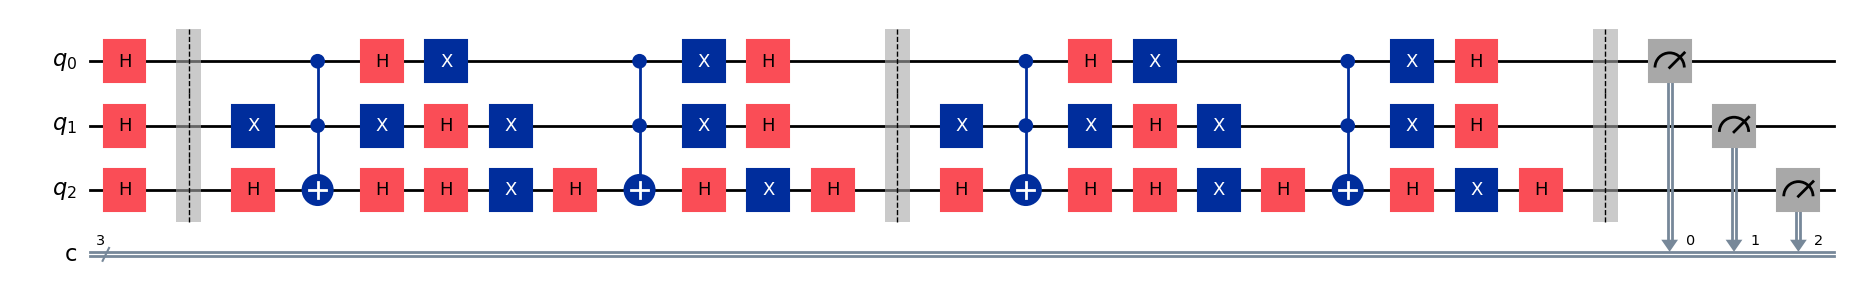

In [6]:
def grover_circuit(n, marked, t=None):
    "Full Grover search over n qubits for the given marked answers."
    if t is None:
        t = optimal_iterations(n, len(marked))

    qc = QuantumCircuit(n, n)

    # start every answer at equal height
    for i in range(n):
        qc.h(i)
    qc.barrier()

    # repeat the two magic moves
    for _ in range(t):
        qc.compose(phase_oracle(n, marked), inplace=True)
        qc.compose(diffuser(n), inplace=True)
        qc.barrier()

    qc.measure(range(n), range(n))
    return qc, t


N_QUBITS = 3
MARKED = ["101"]
qc, t = grover_circuit(N_QUBITS, MARKED)
print(f"Searching {2**N_QUBITS} answers for {MARKED}, using t = {t} rounds")
qc.draw(output="mpl", fold=-1)

## 6. Run it

We run the circuit many times. The marked answer should tower over everything else.

Looking for ['101'] among 8 answers, t = 2 rounds
Landed on a winner 3879/4096 times = 94.7%

  101:  3879  <-- WINNER
  111:    42
  001:    34
  110:    32
  100:    28
  010:    28
  000:    28
  011:    25


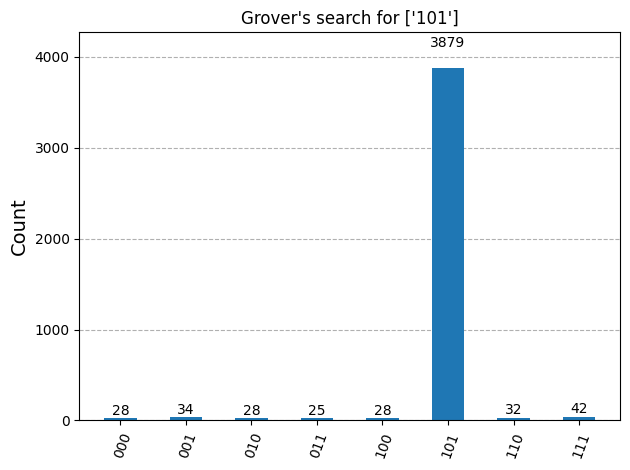

In [7]:
def run_grover(n, marked, shots=4096):
    qc, t = grover_circuit(n, marked)
    sim = AerSimulator()
    counts = sim.run(transpile(qc, sim), shots=shots).result().get_counts()
    return counts, t


N_QUBITS = 3
MARKED = ["101"]
counts, t = run_grover(N_QUBITS, MARKED)

hits = sum(counts.get(m, 0) for m in MARKED)
total = sum(counts.values())
print(f"Looking for {MARKED} among {2**N_QUBITS} answers, t = {t} rounds")
print(f"Landed on a winner {hits}/{total} times = {hits/total:.1%}\n")
for ans in sorted(counts, key=lambda a: -counts[a]):
    star = "  <-- WINNER" if ans in MARKED else ""
    print(f"  {ans}: {counts[ans]:>5}{star}")

plot_histogram(counts, title=f"Grover's search for {MARKED}")

## 7. More than one winner

If several answers are "correct," Grover's finds one of them — and actually needs *fewer* rounds, because more winners means a taller starting signal to amplify. Let's search 16 answers with 4 winners.

Searching 16 answers for 4 winners, t = 1 rounds
Landed on some winner 4096/4096 times = 100.0%

  0100:  1034  <-- winner
  1011:  1027  <-- winner
  1110:  1021  <-- winner
  0001:  1014  <-- winner


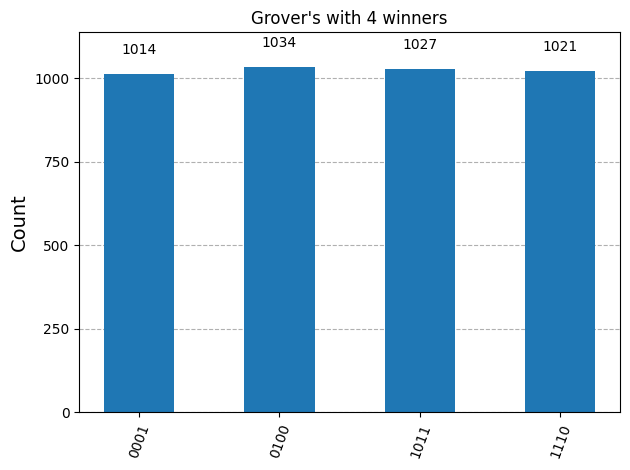

In [8]:
N_QUBITS = 4
MARKED = ["1011", "0100", "1110", "0001"]
counts, t = run_grover(N_QUBITS, MARKED)

hits = sum(counts.get(m, 0) for m in MARKED)
total = sum(counts.values())
print(f"Searching {2**N_QUBITS} answers for {len(MARKED)} winners, t = {t} rounds")
print(f"Landed on some winner {hits}/{total} times = {hits/total:.1%}\n")
for ans in sorted(counts, key=lambda a: -counts[a])[:8]:
    star = "  <-- winner" if ans in MARKED else ""
    print(f"  {ans}: {counts[ans]:>5}{star}")

plot_histogram(counts, title=f"Grover's with {len(MARKED)} winners")

## 8. Seeing the √N speedup

This is the payoff. As the haystack doubles, a classical searcher needs *twice* as many checks. Grover's needs only about **1.4× more** (that's √2). The gap widens fast.

In [9]:
print(f"{'qubits':<8}{'haystack N':<14}{'classical (~N/2)':<20}{'Grover (~t)':<14}")
print("-" * 56)
for n in range(2, 13):
    N = 2 ** n
    classical = N // 2
    grover_t = optimal_iterations(n, 1)
    print(f"{n:<8}{N:<14}{classical:<20}{grover_t:<14}")

print("\nAt 12 qubits (4096 answers): classical ~2048 checks vs Grover ~50.")

qubits  haystack N    classical (~N/2)    Grover (~t)   
--------------------------------------------------------
2       4             2                   1             
3       8             4                   2             
4       16            8                   3             
5       32            16                  4             
6       64            32                  6             
7       128           64                  8             
8       256           128                 12            
9       512           256                 17            
10      1024          512                 25            
11      2048          1024                35            
12      4096          2048                50            

At 12 qubits (4096 answers): classical ~2048 checks vs Grover ~50.


## 9. The whole family, side by side

You've now seen (across these notebooks) the major "query" algorithms — the ones where a hidden function is quizzed as few times as possible. Here is how all six relate. Read it top to bottom to watch the ideas build on each other.

| Algorithm | What's hidden | The question it answers | Classical cost | Quantum cost | Speedup | Needs a hidden pattern? |
|---|---|---|---|---|---|---|
| **Deutsch** | 1-bit rule | Are `f(0)` and `f(1)` the same or different? | 2 queries | 1 query | 2x | Tiny (yes) |
| **Deutsch–Jozsa** | n-bit rule | Is `f` constant, or balanced? | ~2^(n-1)+1 | 1 query | Exponential | Yes (promised) |
| **Bernstein–Vazirani** | a secret string `s` | What is `s`? | n queries | 1 query | Linear→1 | Yes (structured) |
| **Simon's** | a secret mirror `s` | What is `s`? | ~2^(n/2) | ~n queries | **Exponential** | Yes (mirror) |
| **Shor's** | a secret rhythm `r` | What is the period? (→ factor a number) | ~exponential | ~n queries | **Exponential** | Yes (rhythm) |
| **Grover's** | a marked needle | Which answer is the winner? | ~N | ~√N | **Quadratic** | **No — pure haystack** |

### The one dividing line to understand

Everything above splits into two camps:

**Camp 1 — "Expose the pattern" (Deutsch through Shor).** These problems come with a *promise*: the function hides a mirror, a rhythm, a secret string. Quantum interference cancels every wrong answer **at once**, so one or a few queries crack it. Because the whole haystack collapses in a single stroke, the speedup is often **exponential**.

**Camp 2 — "No pattern at all" (Grover).** Here the function is a genuine black box — a needle in an unsorted haystack, no promise, no structure. Interference can't cancel everything at once because there's nothing to cancel *against*. So Grover's can only nudge the answer louder step by step, giving a **quadratic** (√N) speedup. Smaller — but it's the *best anyone can ever do* on a structureless search. That's a proven limit, not a temporary one.

### Where Grover's fits with the others

- **Simon's → Shor's** was about *finding hidden structure fast* (the mirror became a rhythm, and factoring fell out).
- **Grover's** is the opposite lesson: *what quantum computers can do even when there's no structure to find.* Less dramatic, but far more widely applicable — any brute-force search can borrow it.

## 10. What Grover's is actually good for

Because it needs *no structure*, Grover's plugs into almost any "try everything" problem:

| Use | How Grover's helps |
|---|---|
| **Cracking a password / key** | Instead of trying all 2^128 keys, try about 2^64. This is why symmetric encryption keys are being **doubled** in length for the quantum era. |
| **Database / list search** | Find a matching record in an unsorted set of N in ~√N looks. |
| **Puzzles & constraints** | Sudoku, scheduling, graph-coloring — anything you'd normally brute-force. |
| **Speeding up other algorithms** | Grover's is a building block inside larger quantum routines (finding a minimum, collision-finding). |

### The honest caveats

- **Quadratic isn't magic.** Halving the *exponent* of a big search is helpful but not world-ending. Grover's won't make an impossible search instant — it makes a slow one faster.
- **The oracle has to be efficient.** Grover's counts *oracle calls*. If recognizing a winner is itself slow, the speedup can wash out.
- **You need to know when to stop.** Over-rotating ruins it (Section 4). If you don't know how many winners exist, you need extra tricks to guess the right number of rounds.
- **Hardware isn't there yet.** Like Shor's, big useful Grover searches need many low-noise qubits that don't exist today.

But unlike Shor's — which threatens encryption — Grover's mostly just means "use longer keys." It's the friendly quantum algorithm: broadly useful, provably optimal, and no one's losing sleep over it.

---

*(c) 2026 David Grunwald. All rights reserved.*